# Visualisation of *Spice* result applied on cardiac differentiation data

# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import plotting_func as pf
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# import matplotlib as mpl
# mpl.rcParams['font.size'] = 15
# mpl.rcParams['axes.titlesize'] = 15
# mpl.rcParams['xtick.labelsize'] = 10
# mpl.rcParams['ytick.labelsize'] = 10
# mpl.rcParams['figure.dpi'] = 300
# mpl.rcParams['savefig.dpi'] = 300

# Load Tables

In [3]:
### Load all tables ###
# Spice results
psc_vs_meso = pd.read_csv("/home/katharina/msc/spice/psc_vs_meso2/spice_result.GOannot.tsv", sep="\t")
psc_meso_expr = pd.read_csv("/home/katharina/msc/spice/psc_vs_meso2/ATx_relexpr_per_gene.tsv", sep="\t")
meso_vs_cardmeso = pd.read_csv("/home/katharina/msc/spice/meso_vs_cardmeso2/spice_result.GOannot.tsv", sep="\t")
meso_cardmeso_expr = pd.read_csv("/home/katharina/msc/spice/meso_vs_cardmeso2/ATx_relexpr_per_gene.tsv", sep="\t")
cardmeso_vs_cm = pd.read_csv("/home/katharina/msc/spice/cardmeso_vs_cm2/spice_result.GOannot.tsv", sep="\t")
cardmeso_cm_expr = pd.read_csv("/home/katharina/msc/spice/cardmeso_vs_cm2/ATx_relexpr_per_gene.tsv", sep="\t")
psc_vs_meso_sc = pd.read_csv("/home/katharina/msc/spice/psc_vs_meso2/ATx_scCounts_per_gene.tsv", sep="\t")
meso_vs_cardmeso_sc = pd.read_csv("/home/katharina/msc/spice/meso_vs_cardmeso2/ATx_scCounts_per_gene.tsv", sep="\t")
cardmeso_vs_cm_sc = pd.read_csv("/home/katharina/msc/spice/cardmeso_vs_cm2/ATx_scCounts_per_gene.tsv", sep="\t")
# Mapping table
mapping = pd.read_csv("/home/katharina/msc/spice/mapping.tsv", sep="\t")
# Deseq results
psc_vs_meso_deseq = pd.read_csv("/home/katharina/msc/deseq2/deseq2.res.all.padj05.psc.vs.meso.tsv", sep="\t") # contrast: mesoderm (up/down in ...), PSC (reference)
meso_vs_cardmeso_deseq = pd.read_csv("/home/katharina/msc/deseq2/deseq2.res.all.padj05.meso.vs.cardmeso.tsv", sep="\t") # contrast: cardiac mesoderm (up/down in ...), mesoderm (reference)
cardmeso_vs_cm_deseq = pd.read_csv("/home/katharina/msc/deseq2/deseq2.res.all.padj05.cardmeso.vs.cm.tsv", sep="\t") # contrast: CM (up/down in ...), cardiac mesoderm (reference)
# DESeq variance-stabilized transformed (vst) values
vst_df = pd.read_csv("/home/katharina/msc/deseq2/vst_expression.tsv", sep="\t")
# metadata
metadata = pd.read_csv("/home/katharina/msc/quant/metadata.txt", sep="\t")

In [4]:
# specify paths
lib_path = "/share/project/katharina/Spice/spice_lib_homo_sapiens_113_3ee/"
fa_index = pf.load_fa_index(lib_path=lib_path)

# Dataset characterization

In [5]:
markergenes = [
    "SOX2", "NANOG", "POU5F1",
    "EOMES", "MESP1", "TBXT",
    "ISL1", "MEIS2", "HAND2", "HAND1",
    "NKX2-5", "TBX5", "MEF2C", "TNNT2", "MYH6"
]

In [6]:
mapping_markergenes = mapping[mapping["gene_symbol"].isin(markergenes)]
mapping_markergenes = mapping_markergenes.drop_duplicates("ensembl_id")
mapping_markergenes

,ensembl_id,ensembl_transcript_id,transcript_id_v113,fas_id,transcript_symbol,transcript_biotype,gene_symbol
9338,ENSG00000118194,ENST00000455702,ENST00000455702.7,ENSP00000402238,TNNT2-208,protein_coding,TNNT2
22724,ENSG00000163508,ENST00000295743,ENST00000295743.8,ENSP00000295743,EOMES-201,protein_coding,EOMES
24215,ENSG00000181449,ENST00000325404,ENST00000325404.3,ENSP00000323588,SOX2-201,protein_coding,SOX2
25400,ENSG00000164107,ENST00000503024,ENST00000503024.1,ENST00000503024,HAND2-202,nonsense_mediated_decay,HAND2
28938,ENSG00000016082,ENST00000230658,ENST00000230658.12,ENSP00000230658,ISL1-201,protein_coding,ISL1
29445,ENSG00000113196,ENST00000231121,ENST00000231121.3,ENSP00000231121,HAND1-201,protein_coding,HAND1
29581,ENSG00000183072,ENST00000329198,ENST00000329198.5,ENSP00000327758,NKX2-5-201,protein_coding,NKX2-5
32712,ENSG00000081189,ENST00000504921,ENST00000504921.7,ENSP00000421925,MEF2C-209,protein_coding,MEF2C
34808,ENSG00000164458,ENST00000366876,ENST00000366876.7,ENSP00000355841,TBXT-203,protein_coding,TBXT
36423,ENSG00000204531,ENST00000259915,ENST00000259915.13,ENSP00000259915,POU5F1-201,protein_coding,POU5F1


In [7]:
mg_ensg_symb_map = dict(zip(mapping_markergenes["ensembl_id"], mapping_markergenes["gene_symbol"]))
markgergenes_ensg = list(mapping_markergenes["ensembl_id"])

In [8]:
mapping_markergenes_thesis = mapping_markergenes[["ensembl_id", "gene_symbol"]]
mapping_markergenes_thesis["ENSEMBL Gene ID"] = mapping_markergenes_thesis["ensembl_id"]
mapping_markergenes_thesis["Gene Symbol"] = mapping_markergenes_thesis["gene_symbol"]
mapping_markergenes_thesis.drop(["ensembl_id", "gene_symbol"], axis=1, inplace=True)
mapping_markergenes_thesis

/tmp/ipykernel_1704900/499385849.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapping_markergenes_thesis["ENSEMBL Gene ID"] = mapping_markergenes_thesis["ensembl_id"]
/tmp/ipykernel_1704900/499385849.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapping_markergenes_thesis["Gene Symbol"] = mapping_markergenes_thesis["gene_symbol"]
/tmp/ipykernel_1704900/499385849.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation

,ENSEMBL Gene ID,Gene Symbol
9338,ENSG00000118194,TNNT2
22724,ENSG00000163508,EOMES
24215,ENSG00000181449,SOX2
25400,ENSG00000164107,HAND2
28938,ENSG00000016082,ISL1
29445,ENSG00000113196,HAND1
29581,ENSG00000183072,NKX2-5
32712,ENSG00000081189,MEF2C
34808,ENSG00000164458,TBXT
36423,ENSG00000204531,POU5F1


In [9]:
# mapping_markergenes_thesis.to_latex("/home/katharina/msc/figures/markergenes.tex", index=False)

In [10]:
#all_m_filt.to_latex(
#     "/home/katharina/msc/figures/AT_numg_tbl.tex",
#     formatters={"AT": fmt_int, "PSC vs. mesoderm": fmt_int, "Mesoderm vs. cardiac mesoderm": fmt_int, "Cardiac mesoderm vs. CM": fmt_int},
#     index=False
# )

In [11]:
vst_df

,ensembl_id,118882_S9,118884_S10,118886_S11,118888_S12,118890_S13,118892_S14,118750_S3,118752_S4,118754_S5,125499_S11,125501_S12,125503_S13
0,ENSG00000000003,12.691790,12.802987,12.704161,12.601918,12.366055,12.608452,12.502646,12.562703,12.604444,12.618469,12.706396,12.774222
1,ENSG00000000005,6.845336,6.895369,6.863938,7.359501,7.278080,8.669191,7.376278,7.128553,7.171675,6.436863,6.441441,6.557518
2,ENSG00000000419,11.625102,11.621921,11.652077,10.918083,11.200166,11.760701,10.794733,10.891903,10.805624,10.770889,10.795474,10.861589
3,ENSG00000000457,8.804785,9.078087,8.956248,9.251314,9.517865,9.280843,9.812464,9.662614,9.901447,9.796761,9.905693,9.909990
4,ENSG00000000460,10.411735,10.400586,10.655893,10.550045,10.645349,11.000761,10.767179,10.730518,10.676709,9.901383,10.147943,10.295027
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19209,ENSG00000293685,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729
19210,ENSG00000293689,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.167729,6.441441,6.167729
19211,ENSG00000293691,6.364987,6.167729,6.167729,6.167729,6.167729,6.370514,6.167729,6.349346,6.361164,6.167729,6.167729,6.167729
19212,ENSG00000300510,7.633064,7.462266,7.902210,8.646842,8.016452,7.599616,7.074623,7.095964,7.253921,6.822297,6.945629,6.849744


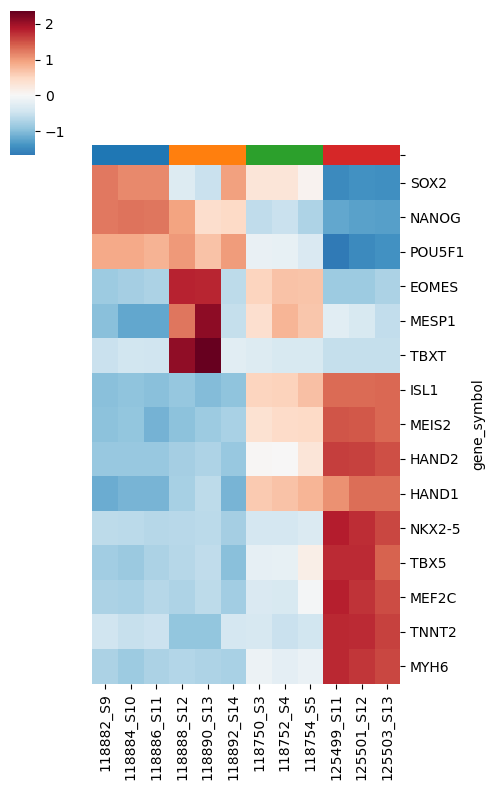

In [12]:
mat, meta_sorted = pf.build_marker_matrix_from_vst(
    vst_df=vst_df,
    marker_symbols_order=markergenes,
    ensg_to_symbol=mg_ensg_symb_map,
    samples_meta=metadata,
    desired_celltype_order=("PSC", "mesoderm", "cardiac mesoderm", "CM"),
    zscore=True
)
pf.plot_marker_heatmap(mat, meta_sorted, figsize=(5, 8))
# plot_marker_heatmap(mat, meta_sorted, figsize=(5, 8), save_path="/home/katharina/msc/figures/markergenes.svg")

# Map transcript IDs to transcript symbols

In [13]:
psc_meso_expr = pf.map_id_to_symbol(expr_df=psc_meso_expr,
                                    mapping=mapping)

In [14]:
meso_cardmeso_expr = pf.map_id_to_symbol(expr_df=meso_cardmeso_expr,
                                        mapping=mapping)

In [15]:
cardmeso_cm_expr = pf.map_id_to_symbol(expr_df=cardmeso_cm_expr,
                                        mapping=mapping)

In [16]:
psc_vs_meso_filt10top100 = psc_vs_meso[(psc_vs_meso["TPM_mean_PSC"] >= 10) & (psc_vs_meso["TPM_mean_mesoderm"] >= 10)].head(100)

In [17]:
print(len(psc_vs_meso[(psc_vs_meso["TPM_mean_PSC"] >= 10) & (psc_vs_meso["TPM_mean_mesoderm"] >= 10)]))

5279


In [18]:
psc_vs_meso_filt10top100.head(50)

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_PSC,TPM_mean_mesoderm,count_scaled_mean_PSC,count_scaled_mean_mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
5,ENSG00000119866,99,0.679554,0.330001,0.373967,0.999808,13.657789,15.980328,1608.236593,1298.863316,BCL11A,{'BCL11 transcription factor A'},"GO:0000122,GO:0006357,GO:0010976,GO:0010977,GO...",negative regulation of transcription by RNA po...,"GO:0000978,GO:0001067,GO:0001227,GO:0003677,GO...",RNA polymerase II cis-regulatory region sequen...
14,ENSG00000174720,99,0.546728,0.479149,0.335983,0.999450,10.314976,28.743318,832.216429,2529.283442,LARP7,{'La-related protein 7'},"GO:0000122,GO:0000494,GO:0006396,GO:0006397,GO...",negative regulation of transcription by RNA po...,"GO:0003676,GO:0003723,GO:0005515,GO:0017070,GO...","nucleic acid binding,RNA binding,protein bindi..."
36,ENSG00000003509,6,0.605747,0.279835,0.294389,0.998085,44.560995,27.120437,1216.041827,1742.704139,NDUFAF7,"{'Protein arginine methyltransferase NDUFAF7, ...","GO:0019918,GO:0032259,GO:0032981","peptidyl-arginine methylation, to symmetrical-...","GO:0005515,GO:0008168,GO:0016740,GO:0019899,GO...","protein binding,methyltransferase activity,tra..."
49,ENSG00000106462,99,0.667918,0.233946,0.269111,0.996942,20.216655,23.048163,2149.246419,3057.895499,EZH2,{'Histone-lysine N-methyltransferase EZH2'},"GO:0000122,GO:0006346,GO:0006357,GO:0010467,GO...",negative regulation of transcription by RNA po...,"GO:1990841,GO:0000978,GO:0000979,GO:0001222,GO...","promoter-specific chromatin binding,RNA polyme..."
65,ENSG00000147162,9,0.834194,0.102697,0.230786,0.995869,63.928271,29.953901,13892.437363,7049.284097,OGT,{'UDP-N-acetylglucosamine--peptide N-acetylglu...,"GO:0006493,GO:0000122,GO:0000423,GO:0000432,GO...","protein O-linked glycosylation,negative regula...","GO:0005515,GO:0005547,GO:0008289,GO:0008375,GO...","protein binding,phosphatidylinositol-3,4,5-tri..."
66,ENSG00000156976,6,0.933347,0.277786,0.258575,0.995802,196.886417,257.518605,11417.969420,18905.373012,EIF4A2,{'Eukaryotic initiation factor 4A-II'},"GO:1990830,GO:0006412,GO:0006413,GO:0006446,GO...",cellular response to leukemia inhibitory facto...,"GO:0000166,GO:0003676,GO:0003723,GO:0003724,GO...","nucleotide binding,nucleic acid binding,RNA bi..."
87,ENSG00000117616,4,1.000000,0.250165,0.310595,0.994626,13.196075,12.126255,760.154768,816.016058,RSRP1,{'Arginine/serine-rich protein 1'},GO:0000245,spliceosomal complex assembly,GO:0005515,protein binding
90,ENSG00000118507,8,0.697854,0.327548,0.252756,0.994338,26.359883,13.622296,1467.595934,913.711405,AKAP7,{'A-kinase anchor protein 7 isoforms alpha and...,"GO:0001508,GO:0006811,GO:0008104,GO:0035556,GO...","action potential,monoatomic ion transport,intr...","GO:0005515,GO:0051018,GO:0000166,GO:0019901,GO...","protein binding,protein kinase A binding,nucle..."
101,ENSG00000197102,99,0.821501,0.324230,0.235996,0.993232,19.691614,21.906916,12577.141195,15322.463153,DYNC1H1,{'Cytoplasmic dynein 1 heavy chain 1'},"GO:0007018,GO:0007052,GO:0032388,GO:0033962,GO...","microtubule-based movement,mitotic spindle org...","GO:0008569,GO:0000166,GO:0003723,GO:0005515,GO...","minus-end-directed microtubule motor activity,..."
112,ENSG00000102710,8,0.536675,0.238215,0.240700,0.992655,28.386270,29.380491,2682.802314,3225.708020,SUPT20H,{'Transcription factor SPT20 homolog'},"GO:0006282,GO:0006914,GO:0007369,GO:0043484,GO...","regulation of DNA repair,autophagy,gastrulatio...","GO:0003712,GO:0005515","transcription coregulator activity,protein bin..."


In [19]:
meso_vs_cardmeso_filt10top100 = meso_vs_cardmeso[(meso_vs_cardmeso["TPM_mean_mesoderm"] >= 10) & (meso_vs_cardmeso["TPM_mean_cardiac mesoderm"] >= 10)].head(100)

In [20]:
print(len(meso_vs_cardmeso[(meso_vs_cardmeso["TPM_mean_mesoderm"] >= 10) & (meso_vs_cardmeso["TPM_mean_cardiac mesoderm"] >= 10)]))

5434


In [21]:
meso_vs_cardmeso_filt10top100.head(50)

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_cardiac mesoderm,TPM_mean_mesoderm,count_scaled_mean_cardiac mesoderm,count_scaled_mean_mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
49,ENSG00000133026,9,0.417006,0.150850,0.265648,0.996114,58.832432,49.653675,19924.490372,21755.278379,MYH10,{'Myosin-10'},"GO:0000281,GO:0001701,GO:0001764,GO:0001778,GO...","mitotic cytokinesis,in utero embryonic develop...","GO:0000146,GO:0051015,GO:0000166,GO:0001618,GO...","microfilament motor activity,actin filament bi..."
79,ENSG00000117262,4,0.546950,0.193227,0.305530,0.994353,27.369073,19.851408,1549.025377,1540.026650,GPR89A,{'Golgi pH regulator A'},"GO:0006811,GO:0015031,GO:0030217,GO:0034220,GO...","monoatomic ion transport,protein transport,T c...",GO:0008308,voltage-gated monoatomic anion channel activity
87,ENSG00000129197,8,0.838568,0.132094,0.242103,0.994002,48.914511,61.442159,2896.015571,3332.440760,RPAIN,{'RPA-interacting protein'},"GO:0006606,GO:0009411","protein import into nucleus,response to UV","GO:0005515,GO:0008270,GO:0046872","protein binding,zinc ion binding,metal ion bin..."
103,ENSG00000180901,2,1.000000,0.417967,0.485798,0.993037,17.936913,32.994360,2277.973500,5471.645642,KCTD2,{'BTB/POZ domain-containing protein KCTD2'},"GO:0051260,GO:0043161","protein homooligomerization,proteasome-mediate...","GO:0005515,GO:0044877,GO:0097602","protein binding,protein-containing complex bin..."
106,ENSG00000162613,6,0.453893,0.147074,0.257843,0.992587,135.396420,170.520238,11252.076471,11358.467016,FUBP1,{'Far upstream element-binding protein 1'},"GO:0010468,GO:0010628,GO:0006357","regulation of gene expression,positive regulat...","GO:0003676,GO:0003677,GO:0003697,GO:0003723,GO...","nucleic acid binding,DNA binding,single-strand..."
113,ENSG00000197102,99,0.823250,0.348525,0.225501,0.992004,18.142746,22.687666,10976.148450,15823.327122,DYNC1H1,{'Cytoplasmic dynein 1 heavy chain 1'},"GO:0007018,GO:0007052,GO:0032388,GO:0033962,GO...","microtubule-based movement,mitotic spindle org...","GO:0008569,GO:0000166,GO:0003723,GO:0005515,GO...","minus-end-directed microtubule motor activity,..."
120,ENSG00000123737,4,0.575067,0.091717,0.279641,0.991556,46.144830,45.193904,3065.662371,3626.218970,EXOSC9,{'Exosome complex component RRP45'},"GO:0000956,GO:0006364,GO:0006396,GO:0006401,GO...","nuclear-transcribed mRNA catabolic process,rRN...","GO:0004532,GO:0000175,GO:0003723,GO:0005515,GO...","RNA exonuclease activity,3'-5'-RNA exonuclease..."
124,ENSG00000119682,4,0.589258,0.163461,0.277463,0.991270,15.318684,11.543179,2835.991782,2734.851290,AREL1,{'Apoptosis-resistant E3 ubiquitin protein lig...,"GO:0006511,GO:0006915,GO:0016567,GO:0043066,GO...","ubiquitin-dependent protein catabolic process,...","GO:0004842,GO:0005515,GO:0016740,GO:0061630","ubiquitin-protein transferase activity,protein..."
128,ENSG00000125967,4,0.845792,0.136095,0.274642,0.990885,17.181168,10.230530,1149.304082,875.424121,NECAB3,{'N-terminal EF-hand calcium-binding protein 3'},"GO:0009306,GO:0019538,GO:0042984","protein secretion,protein metabolic process,re...","GO:0005509,GO:0005515,GO:0046872","calcium ion binding,protein binding,metal ion ..."
142,ENSG00000096696,9,0.668732,0.345471,0.223026,0.989856,45.014408,34.880317,16659.981547,15329.819482,DSP,{'Desmoplakin'},"GO:0034332,GO:0043588,GO:0045104,GO:0090136,GO...","adherens junction organization,skin developmen...","GO:0003723,GO:0005080,GO:0005200,GO:0005515,GO...","RNA binding,protein kinase C binding,structura..."


In [22]:
cardmeso_vs_cm_filt10top100 = cardmeso_vs_cm[(cardmeso_vs_cm["TPM_mean_cardiac mesoderm"] >= 10) & (cardmeso_vs_cm["TPM_mean_CM"] >= 10)].head(100)

In [23]:
print(len(cardmeso_vs_cm[(cardmeso_vs_cm["TPM_mean_cardiac mesoderm"] >= 10) & (cardmeso_vs_cm["TPM_mean_CM"] >= 10)]))

5692


In [24]:
cardmeso_vs_cm_filt10top100.head(50)

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_CM,TPM_mean_cardiac mesoderm,count_scaled_mean_CM,count_scaled_mean_cardiac mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
1,ENSG00000179364,5,0.711785,0.610042,0.589079,1.000000,21.070619,15.205507,3596.033395,2631.944236,PACS2,{'Phosphofurin acidic cluster sorting protein 2'},"GO:0000045,GO:0034497,GO:0006915,GO:0032469,GO...","autophagosome assembly,protein localization to...","GO:0005515,GO:0044325","protein binding,transmembrane transporter binding"
16,ENSG00000096696,99,0.734986,0.306737,0.257145,0.999830,106.905294,45.038846,44797.648959,16663.981652,DSP,{'Desmoplakin'},"GO:0034332,GO:0043588,GO:0045104,GO:0090136,GO...","adherens junction organization,skin developmen...","GO:0003723,GO:0005080,GO:0005200,GO:0005515,GO...","RNA binding,protein kinase C binding,structura..."
18,ENSG00000204681,9,0.600628,0.163469,0.270375,0.999763,14.464849,26.607760,2257.348351,3924.497085,GABBR1,{'Gamma-aminobutyric acid type B receptor subu...,"GO:0007214,GO:0001649,GO:0007165,GO:0007186,GO...","gamma-aminobutyric acid signaling pathway,oste...","GO:0004965,GO:0004930,GO:0005515,GO:0016917,GO...","G protein-coupled GABA receptor activity,G pro..."
26,ENSG00000174720,99,0.644099,0.186604,0.231482,0.999548,29.995490,16.165528,2534.946161,1249.031185,LARP7,{'La-related protein 7'},"GO:0000122,GO:0000494,GO:0006396,GO:0006397,GO...",negative regulation of transcription by RNA po...,"GO:0003676,GO:0003723,GO:0005515,GO:0017070,GO...","nucleic acid binding,RNA binding,protein bindi..."
40,ENSG00000125967,5,0.738250,0.141158,0.278640,0.999122,26.370978,17.181168,1839.202584,1149.304082,NECAB3,{'N-terminal EF-hand calcium-binding protein 3'},"GO:0009306,GO:0019538,GO:0042984","protein secretion,protein metabolic process,re...","GO:0005509,GO:0005515,GO:0046872","calcium ion binding,protein binding,metal ion ..."
49,ENSG00000108515,8,0.429239,0.218681,0.208486,0.998852,168.559600,21.186954,10407.306779,998.656722,ENO3,{'Beta-enolase'},"GO:0006094,GO:0006096,GO:0061621","gluconeogenesis,glycolytic process,canonical g...","GO:0000287,GO:0004634,GO:0005515,GO:0016829,GO...","magnesium ion binding,phosphopyruvate hydratas..."
50,ENSG00000139687,5,0.711250,0.187338,0.266336,0.998808,16.328915,10.876982,2161.059270,1263.458610,RB1,{'Retinoblastoma-associated protein'},"GO:2000045,GO:2000134,GO:0000082,GO:0000122,GO...",regulation of G1/S transition of mitotic cell ...,"GO:0003677,GO:0003714,GO:0005515,GO:0019899,GO...","DNA binding,transcription corepressor activity..."
64,ENSG00000173575,8,0.929823,0.085056,0.193534,0.998117,34.573582,23.183553,9698.215771,6207.902197,CHD2,{'Chromodomain-helicase-DNA-binding protein 2'},"GO:0006974,GO:0060218,GO:0006325,GO:0006338,GO...","DNA damage response,hematopoietic stem cell di...","GO:0000166,GO:0000978,GO:0003677,GO:0003723,GO...","nucleotide binding,RNA polymerase II cis-regul..."
69,ENSG00000241343,5,0.708270,0.306868,0.243089,0.997900,1722.623341,929.221315,25932.417266,10364.970073,RPL36A,{'Large ribosomal subunit protein eL42'},"GO:0002181,GO:0006412,GO:0006941,GO:1901740","cytoplasmic translation,translation,striated m...","GO:0003723,GO:0003735,GO:0005515","RNA binding,structural constituent of ribosome..."
70,ENSG00000112531,9,0.577057,0.101625,0.203644,0.997813,141.726443,66.908988,18580.064832,7376.317518,QKI,{'KH domain-containing RNA-binding protein QKI'},"GO:0001570,GO:0007286,GO:0008366,GO:0010628,GO...","vasculogenesis,spermatid development,axon ensh...","GO:0003676,GO:0003677,GO:0003713,GO:0003723,GO...","nucleic acid binding,DNA binding,transcription..."


# DIDO1

In [25]:
psc_vs_meso_filt10top100[psc_vs_meso_filt10top100["gene_symbol"] == "DIDO1"]

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_PSC,TPM_mean_mesoderm,count_scaled_mean_PSC,count_scaled_mean_mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
296,ENSG00000101191,5,0.29654,0.281122,0.211228,0.975895,48.538452,29.875753,13582.137451,6213.740637,DIDO1,{'Death-inducer obliterator 1'},"GO:0097190,GO:0006351,GO:0006915","apoptotic signaling pathway,DNA-templated tran...","GO:0003723,GO:0005515,GO:0008270,GO:0046872","RNA binding,protein binding,zinc ion binding,m..."


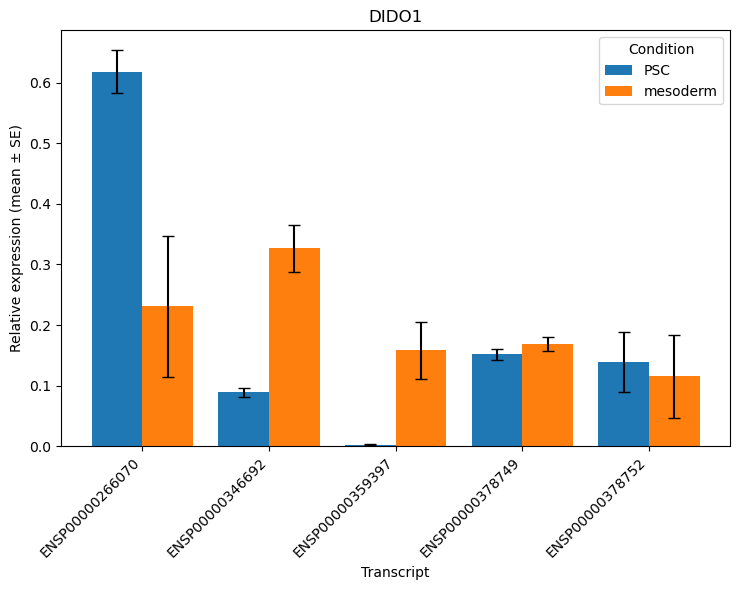

In [26]:
pf.plot_expr_bars(expr_df=psc_meso_expr,
                   gene="DIDO1",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["PSC", "mesoderm"],
                   how="rel",
                   by="ensembl")

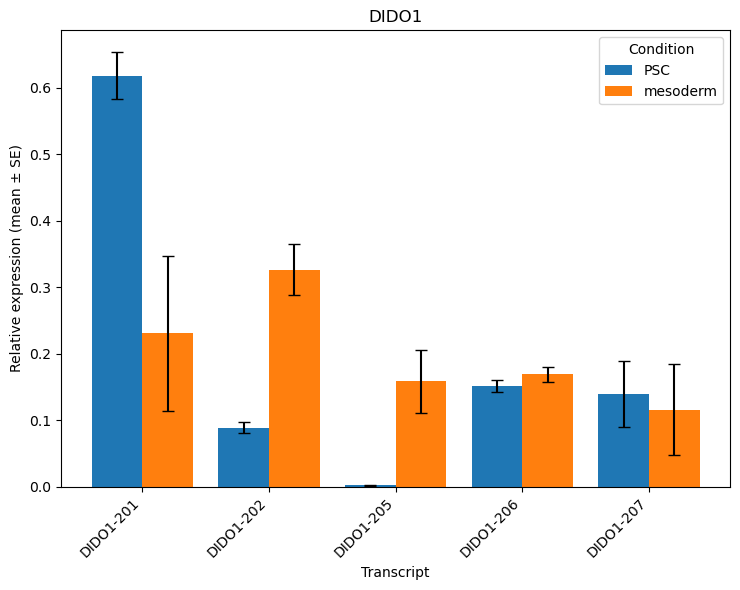

In [27]:
pf.plot_expr_bars(expr_df=psc_meso_expr,
                   gene="DIDO1",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["PSC", "mesoderm"],
                   how="rel",
                   by="symbol")

In [28]:
#fig = pf.feature_architecture_figure(lib_path=lib_path, gene_id="ENSG00000101191", expr_df=psc_meso_expr, fa_index=fa_index)

In [29]:
pf.feature_architecture_figure(lib_path=lib_path, gene_id="ENSG00000101191", expr_df=psc_meso_expr, fa_index=fa_index)

In [30]:
list(psc_vs_meso_filt10top100[psc_vs_meso_filt10top100["gene_symbol"] == "DIDO1"]["BP_GO_Desc"])

['apoptotic signaling pathway,DNA-templated transcription,apoptotic process']

In [31]:
psc_meso_expr[psc_meso_expr["gene_symbol"] == "DIDO1"]

,gene,Name,txname,rel_expr_118882_S9_PSC,rel_expr_118884_S10_PSC,rel_expr_118886_S11_PSC,rel_expr_118888_S12_mesoderm,rel_expr_118890_S13_mesoderm,rel_expr_118892_S14_mesoderm,gene_symbol,transcript_symbol
9537,ENSG00000101191,ENSP00000266070,ENST00000266070,0.549850,0.668659,0.637182,0.000000,0.315145,0.377236,DIDO1,DIDO1-201
9538,ENSG00000101191,ENSP00000378752,ENST00000395343,0.238590,0.085763,0.093610,0.237099,0.109248,0.000000,DIDO1,DIDO1-207
9539,ENSG00000101191,ENSP00000378749,ENST00000395340,0.135811,0.152014,0.166947,0.145689,0.180115,0.180615,DIDO1,DIDO1-206
9540,ENSG00000101191,ENSP00000359397,ENST00000370371,0.003203,0.000000,0.002683,0.245195,0.145620,0.084221,DIDO1,DIDO1-205
9541,ENSG00000101191,ENSP00000346692,ENST00000354665,0.072546,0.093563,0.099578,0.372017,0.249872,0.357928,DIDO1,DIDO1-202


In [32]:
psc_vs_meso_sc[psc_vs_meso_sc["gene"] == "ENSG00000101191"]

,gene,Name,txname,count_scaled_118882_S9_PSC,count_scaled_118884_S10_PSC,count_scaled_118886_S11_PSC,count_scaled_118888_S12_mesoderm,count_scaled_118890_S13_mesoderm,count_scaled_118892_S14_mesoderm
9537,ENSG00000101191,ENSP00000266070,ENST00000266070,7831.715634,8650.840010,8643.661427,0.000000,1741.316210,2543.587835
9538,ENSG00000101191,ENSP00000378752,ENST00000395343,3398.331613,1109.566354,1269.855947,1511.053465,603.645001,0.000000
9539,ENSG00000101191,ENSP00000378749,ENST00000395340,1934.408180,1966.699948,2264.712179,928.487178,995.212987,1217.832808
9540,ENSG00000101191,ENSP00000359397,ENST00000370371,45.621805,0.000000,36.401275,1562.646730,804.614522,567.878265
9541,ENSG00000101191,ENSP00000346692,ENST00000354665,1033.298594,1210.484828,1350.814559,2370.894985,1380.649884,2413.402039


In [33]:
psc_vs_meso_deseq[psc_vs_meso_deseq["GeneSymbol"] == "DIDO1"]

,GeneID,GeneSymbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
2398,ENSG00000101191,DIDO1,8476.644661,-0.75482,0.125058,-6.035759,1.582173e-09,1.700322e-08,True


# METTL3

In [34]:
psc_vs_meso_filt10top100[psc_vs_meso_filt10top100["gene_symbol"] == "METTL3"]

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_PSC,TPM_mean_mesoderm,count_scaled_mean_PSC,count_scaled_mean_mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
163,ENSG00000165819,5,1.0,0.215876,0.260218,0.988972,56.13775,45.116551,4258.787288,4707.619222,METTL3,{'N(6)-adenosine-methyltransferase catalytic s...,"GO:0000398,GO:0001510,GO:0002376,GO:0006397,GO...","mRNA splicing, via spliceosome,RNA methylation...","GO:1990931,GO:0001734,GO:0003723,GO:0003729,GO...","mRNA N6-methyladenosine dioxygenase activity,m..."


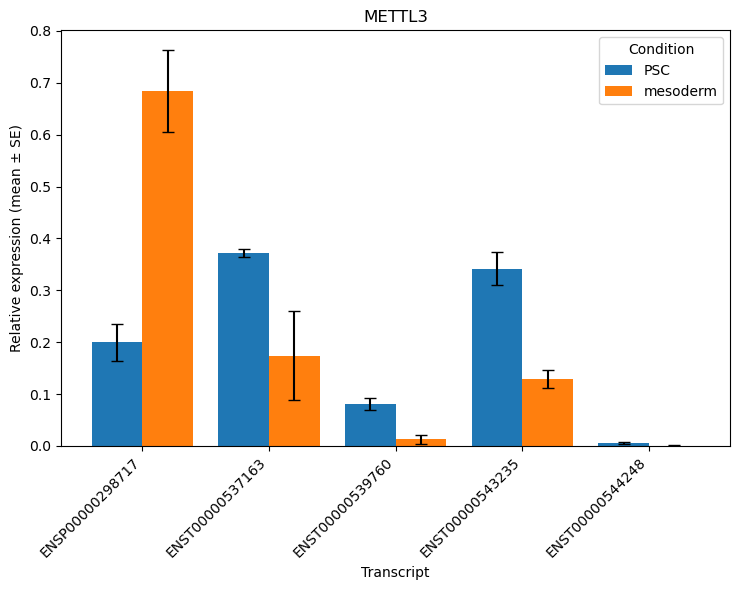

In [35]:
pf.plot_expr_bars(expr_df=psc_meso_expr,
                   gene="METTL3",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["PSC", "mesoderm"],
                   how="rel",
                   by="ensembl")

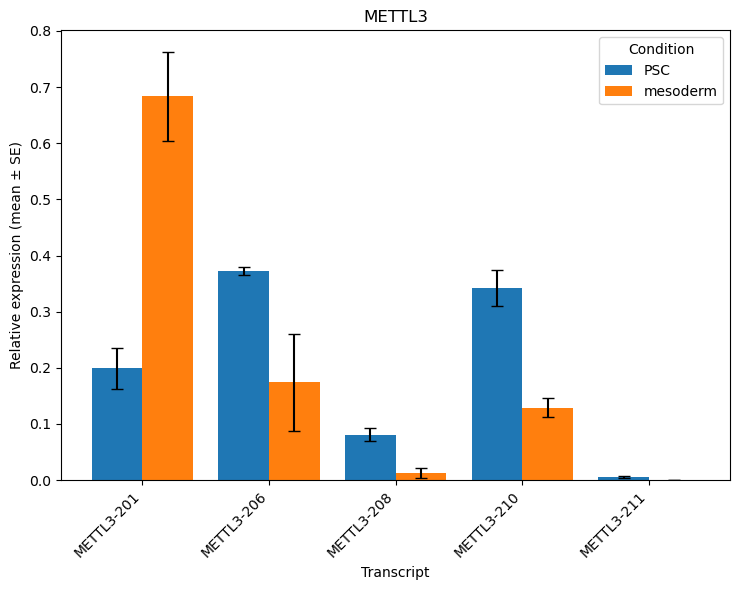

In [36]:
pf.plot_expr_bars(expr_df=psc_meso_expr,
                   gene="METTL3",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["PSC", "mesoderm"],
                   how="rel",
                   by="symbol")

In [37]:
list(psc_vs_meso_filt10top100[psc_vs_meso_filt10top100["gene_symbol"] == "METTL3"]["BP_GO_Desc"])

['mRNA splicing, via spliceosome,RNA methylation,immune system process,mRNA processing,DNA damage response,spermatogenesis,circadian rhythm,dosage compensation by inactivation of X chromosome,mRNA modification,stem cell population maintenance,forebrain radial glial cell differentiation,cell differentiation,primary miRNA processing,methylation,cellular response to UV,gliogenesis,RNA stabilization,innate immune response,regulation of T cell differentiation,positive regulation of translation,negative regulation of Notch signaling pathway,oogenesis,rhythmic process,regulation of meiotic cell cycle,negative regulation of type I interferon-mediated signaling pathway,mRNA destabilization,endothelial to hematopoietic transition,regulation of hematopoietic stem cell differentiation,positive regulation of cap-independent translational initiation']

In [38]:
psc_vs_meso_deseq[psc_vs_meso_deseq["GeneSymbol"] == "METTL3"]

,GeneID,GeneSymbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
11282,ENSG00000165819,METTL3,4181.033638,-0.269943,0.25973,-1.039325,0.298654,0.415145,False


In [39]:
meso_vs_cardmeso_filt10top100[meso_vs_cardmeso_filt10top100["gene_symbol"] == "METTL3"]

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_cardiac mesoderm,TPM_mean_mesoderm,count_scaled_mean_cardiac mesoderm,count_scaled_mean_mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
197,ENSG00000165819,4,1.0,0.132436,0.239701,0.984574,63.30509,45.082145,4675.787964,4704.069206,METTL3,{'N(6)-adenosine-methyltransferase catalytic s...,"GO:0000398,GO:0001510,GO:0002376,GO:0006397,GO...","mRNA splicing, via spliceosome,RNA methylation...","GO:1990931,GO:0001734,GO:0003723,GO:0003729,GO...","mRNA N6-methyladenosine dioxygenase activity,m..."


In [40]:
meso_vs_cardmeso_deseq[meso_vs_cardmeso_deseq["GeneSymbol"] == "METTL3"]

,GeneID,GeneSymbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
11282,ENSG00000165819,METTL3,4181.033638,0.377675,0.259685,1.45436,0.145847,0.236574,False


In [41]:
cardmeso_vs_cm_filt10top100[cardmeso_vs_cm_filt10top100["gene_symbol"] == "METTL3"]

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_CM,TPM_mean_cardiac mesoderm,count_scaled_mean_CM,count_scaled_mean_cardiac mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc


In [42]:
cardmeso_vs_cm[cardmeso_vs_cm["gene_symbol"] == "METTL3"]

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_CM,TPM_mean_cardiac mesoderm,count_scaled_mean_CM,count_scaled_mean_cardiac mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
547,ENSG00000165819,4,1.0,0.035391,0.119034,0.955658,30.573309,63.30509,2468.379424,4675.787964,METTL3,{'N(6)-adenosine-methyltransferase catalytic s...,"GO:0000398,GO:0001510,GO:0002376,GO:0006397,GO...","mRNA splicing, via spliceosome,RNA methylation...","GO:1990931,GO:0001734,GO:0003723,GO:0003729,GO...","mRNA N6-methyladenosine dioxygenase activity,m..."


In [43]:
cardmeso_vs_cm_deseq[cardmeso_vs_cm_deseq["GeneSymbol"] == "METTL3"]

,GeneID,GeneSymbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
11282,ENSG00000165819,METTL3,4181.033638,-1.244252,0.259661,-4.791829,0.000002,0.000011,True


In [44]:
psc_meso_expr[psc_meso_expr["gene_symbol"] == "METTL3"]

,gene,Name,txname,rel_expr_118882_S9_PSC,rel_expr_118884_S10_PSC,rel_expr_118886_S11_PSC,rel_expr_118888_S12_mesoderm,rel_expr_118890_S13_mesoderm,rel_expr_118892_S14_mesoderm,gene_symbol,transcript_symbol
20004,ENSG00000165819,ENST00000539760,ENST00000539760,0.060640,0.082430,0.099474,0.003029,0.004814,0.030972,METTL3,METTL3-208
20005,ENSG00000165819,ENSP00000298717,ENST00000298717,0.260379,0.203491,0.134495,0.766456,0.759255,0.524832,METTL3,METTL3-201
20006,ENSG00000165819,ENST00000537163,ENST00000537163,0.386691,0.370907,0.359948,0.099750,0.077077,0.344757,METTL3,METTL3-206
20007,ENSG00000165819,ENST00000543235,ENST00000543235,0.286458,0.340080,0.398238,0.130766,0.158854,0.097920,METTL3,METTL3-210
20008,ENSG00000165819,ENST00000544248,ENST00000544248,0.005832,0.003092,0.007845,0.000000,0.000000,0.001519,METTL3,METTL3-211


In [45]:
psc_vs_meso_sc[psc_vs_meso_sc["gene"] == "ENSG00000165819"]

,gene,Name,txname,count_scaled_118882_S9_PSC,count_scaled_118884_S10_PSC,count_scaled_118886_S11_PSC,count_scaled_118888_S12_mesoderm,count_scaled_118890_S13_mesoderm,count_scaled_118892_S14_mesoderm
20004,ENSG00000165819,ENST00000539760,ENST00000539760,264.632295,351.861866,412.197155,10.818151,17.040193,217.154064
20005,ENSG00000165819,ENSP00000298717,ENST00000298717,1136.298270,868.620770,557.313975,2737.789711,2687.375352,3679.781049
20006,ENSG00000165819,ENST00000537163,ENST00000537163,1687.524927,1583.248381,1491.539468,356.306698,272.813882,2417.216415
20007,ENSG00000165819,ENST00000543235,ENST00000543235,1250.104254,1451.660942,1650.203891,467.098829,562.260739,686.552536
20008,ENSG00000165819,ENST00000544248,ENST00000544248,25.452090,13.197209,32.506370,0.000000,0.000000,10.650047


In [46]:
meso_cardmeso_expr[meso_cardmeso_expr["gene_symbol"] == "METTL3"]

,gene,Name,txname,rel_expr_118750_S3_cardiac mesoderm,rel_expr_118752_S4_cardiac mesoderm,rel_expr_118754_S5_cardiac mesoderm,rel_expr_118888_S12_mesoderm,rel_expr_118890_S13_mesoderm,rel_expr_118892_S14_mesoderm,gene_symbol,transcript_symbol
19427,ENSG00000165819,ENST00000539760,ENST00000539760,0.020301,0.011651,0.024136,0.003029,0.004814,0.031019,METTL3,METTL3-208
19428,ENSG00000165819,ENSP00000298717,ENST00000298717,0.303671,0.299969,0.316864,0.766456,0.759255,0.525630,METTL3,METTL3-201
19429,ENSG00000165819,ENST00000537163,ENST00000537163,0.337112,0.375612,0.297520,0.099750,0.077077,0.345282,METTL3,METTL3-206
19430,ENSG00000165819,ENST00000543235,ENST00000543235,0.338916,0.312768,0.361480,0.130766,0.158854,0.098069,METTL3,METTL3-210


In [47]:
meso_vs_cardmeso_sc[meso_vs_cardmeso_sc["gene"] == "ENSG00000165819"]

,gene,Name,txname,count_scaled_118750_S3_cardiac mesoderm,count_scaled_118752_S4_cardiac mesoderm,count_scaled_118754_S5_cardiac mesoderm,count_scaled_118888_S12_mesoderm,count_scaled_118890_S13_mesoderm,count_scaled_118892_S14_mesoderm
19427,ENSG00000165819,ENST00000539760,ENST00000539760,99.098651,57.012814,102.636087,10.818151,17.040193,217.154064
19428,ENSG00000165819,ENSP00000298717,ENST00000298717,1482.330132,1467.902612,1347.458779,2737.789711,2687.375352,3679.781049
19429,ENSG00000165819,ENST00000537163,ENST00000537163,1645.565794,1838.066943,1265.198018,356.306698,272.813882,2417.216415
19430,ENSG00000165819,ENST00000543235,ENST00000543235,1654.372831,1530.536965,1537.184265,467.098829,562.260739,686.552536


In [48]:
cardmeso_cm_expr[cardmeso_cm_expr["gene_symbol"] == "METTL3"]

,gene,Name,txname,rel_expr_118750_S3_cardiac mesoderm,rel_expr_118752_S4_cardiac mesoderm,rel_expr_118754_S5_cardiac mesoderm,rel_expr_125499_S11_CM,rel_expr_125501_S12_CM,rel_expr_125503_S13_CM,gene_symbol,transcript_symbol
19868,ENSG00000165819,ENST00000539760,ENST00000539760,0.020301,0.011651,0.024136,0.005610,0.011291,0.014208,METTL3,METTL3-208
19869,ENSG00000165819,ENSP00000298717,ENST00000298717,0.303671,0.299969,0.316864,0.545736,0.488827,0.427517,METTL3,METTL3-201
19870,ENSG00000165819,ENST00000537163,ENST00000537163,0.337112,0.375612,0.297520,0.171648,0.148315,0.265120,METTL3,METTL3-206
19871,ENSG00000165819,ENST00000543235,ENST00000543235,0.338916,0.312768,0.361480,0.277006,0.351568,0.293155,METTL3,METTL3-210


In [49]:
meso_vs_cardmeso_sc[meso_vs_cardmeso_sc["gene"] == "ENSG00000165819"]

,gene,Name,txname,count_scaled_118750_S3_cardiac mesoderm,count_scaled_118752_S4_cardiac mesoderm,count_scaled_118754_S5_cardiac mesoderm,count_scaled_118888_S12_mesoderm,count_scaled_118890_S13_mesoderm,count_scaled_118892_S14_mesoderm
19427,ENSG00000165819,ENST00000539760,ENST00000539760,99.098651,57.012814,102.636087,10.818151,17.040193,217.154064
19428,ENSG00000165819,ENSP00000298717,ENST00000298717,1482.330132,1467.902612,1347.458779,2737.789711,2687.375352,3679.781049
19429,ENSG00000165819,ENST00000537163,ENST00000537163,1645.565794,1838.066943,1265.198018,356.306698,272.813882,2417.216415
19430,ENSG00000165819,ENST00000543235,ENST00000543235,1654.372831,1530.536965,1537.184265,467.098829,562.260739,686.552536


In [50]:
meso_vs_cardmeso_filt10top100[meso_vs_cardmeso_filt10top100["gene_symbol"] == "METTL3"]

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_cardiac mesoderm,TPM_mean_mesoderm,count_scaled_mean_cardiac mesoderm,count_scaled_mean_mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
197,ENSG00000165819,4,1.0,0.132436,0.239701,0.984574,63.30509,45.082145,4675.787964,4704.069206,METTL3,{'N(6)-adenosine-methyltransferase catalytic s...,"GO:0000398,GO:0001510,GO:0002376,GO:0006397,GO...","mRNA splicing, via spliceosome,RNA methylation...","GO:1990931,GO:0001734,GO:0003723,GO:0003729,GO...","mRNA N6-methyladenosine dioxygenase activity,m..."


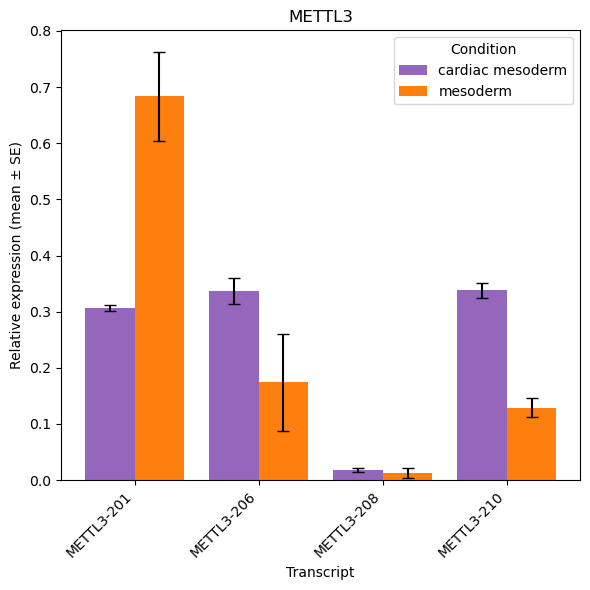

In [51]:
pf.plot_expr_bars(expr_df=meso_cardmeso_expr,
                   gene="METTL3",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["mesoderm", "cardiac mesoderm"],
                   how="rel",
                   by="symbol",
                   condition_colors={"mesoderm": "tab:orange", "cardiac mesoderm": "tab:purple"})

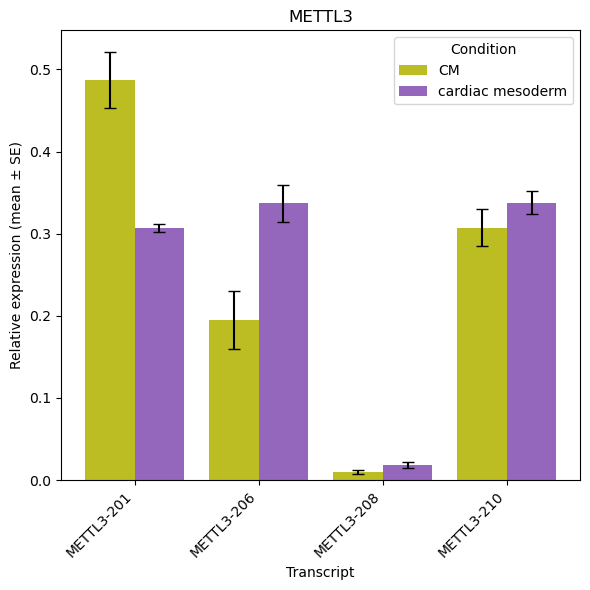

In [52]:
pf.plot_expr_bars(expr_df=cardmeso_cm_expr,
                   gene="METTL3",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["cardiac mesoderm", "CM"],
                   how="rel",
                   by="symbol",
                   condition_colors={"cardiac mesoderm": "tab:purple", "CM": "tab:olive"})

In [53]:
pf.feature_architecture_figure(lib_path=lib_path, gene_id="ENSG00000165819", expr_df=psc_meso_expr, fa_index=fa_index, isoforms=["ENSP00000298717"])

In [54]:
#fig = pf.feature_architecture_figure(lib_path=lib_path, gene_id="ENSG00000165819", expr_df=psc_meso_expr, fa_index=fa_index)
#fig.write_image("/home/katharina/msc/figures/mettl3_faplot.svg")

# BMPR1A

In [55]:
meso_vs_cardmeso_filt10top100[meso_vs_cardmeso_filt10top100["gene_symbol"] =="BMPR1A"]

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_cardiac mesoderm,TPM_mean_mesoderm,count_scaled_mean_cardiac mesoderm,count_scaled_mean_mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
350,ENSG00000107779,9,0.7233,0.106447,0.172136,0.969912,35.40407,27.461337,4889.410394,4577.28122,BMPR1A,{'Bone morphogenetic protein receptor type-1A'},"GO:0010665,GO:1905292,GO:0010628,GO:0001701,GO...",regulation of cardiac muscle cell apoptotic pr...,"GO:0000166,GO:0004672,GO:0004674,GO:0004675,GO...","nucleotide binding,protein kinase activity,pro..."


In [56]:
meso_cardmeso_expr[meso_cardmeso_expr["gene_symbol"] == "BMPR1A"]

,gene,Name,txname,rel_expr_118750_S3_cardiac mesoderm,rel_expr_118752_S4_cardiac mesoderm,rel_expr_118754_S5_cardiac mesoderm,rel_expr_118888_S12_mesoderm,rel_expr_118890_S13_mesoderm,rel_expr_118892_S14_mesoderm,gene_symbol,transcript_symbol
26650,ENSG00000107779,ENSP00000518971,ENST00000713669,0.008416,0.014164,0.008077,0.024112,0.009223,0.003426,BMPR1A,BMPR1A-206
26651,ENSG00000107779,ENST00000635816,ENST00000635816,0.019419,0.018583,0.025942,0.011002,0.013223,0.012916,BMPR1A,BMPR1A-203
26652,ENSG00000107779,ENST00000638429,ENST00000638429,0.062206,0.054914,0.056808,0.074873,0.059950,0.095447,BMPR1A,BMPR1A-205
26653,ENSG00000107779,ENST00000636056,ENST00000636056,0.038180,0.067816,0.101242,0.205231,0.120771,0.074346,BMPR1A,BMPR1A-204
26654,ENSG00000107779,ENSP00000361107,ENST00000372037,0.493950,0.487304,0.454565,0.262116,0.215999,0.757246,BMPR1A,BMPR1A-201
26655,ENSG00000107779,ENSP00000518974,ENST00000713672,0.016060,0.031885,0.020453,0.012873,0.035182,0.000000,BMPR1A,BMPR1A-209
26656,ENSG00000107779,ENST00000713674,ENST00000713674,0.248312,0.269052,0.248083,0.358439,0.384555,0.000000,BMPR1A,BMPR1A-211
26657,ENSG00000107779,ENSP00000483569,ENST00000480152,0.066409,0.056281,0.061628,0.030224,0.103121,0.044448,BMPR1A,BMPR1A-202
26658,ENSG00000107779,ENSP00000518977,ENST00000713675,0.047048,0.000000,0.023202,0.021130,0.057976,0.012171,BMPR1A,BMPR1A-212


In [57]:
meso_vs_cardmeso_deseq[meso_vs_cardmeso_deseq["GeneSymbol"] == "BMPR1A"]

,GeneID,GeneSymbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
3359,ENSG00000107779,BMPR1A,6034.164693,0.44738,0.219262,2.040391,0.041311,0.084418,False


In [58]:
psc_vs_meso_deseq[psc_vs_meso_deseq["GeneSymbol"] == "BMP4"]

,GeneID,GeneSymbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
5470,ENSG00000125378,BMP4,3361.172062,1.743139,0.225624,7.725873,1.110892e-14,2.518529e-13,True


In [59]:
meso_vs_cardmeso_deseq[meso_vs_cardmeso_deseq["GeneSymbol"] == "BMP4"]

,GeneID,GeneSymbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
5470,ENSG00000125378,BMP4,3361.172062,2.014828,0.221853,9.08183,1.067640e-19,5.077425e-18,True


In [60]:
x = meso_cardmeso_expr[meso_cardmeso_expr["gene_symbol"] == "BMPR1A"]
map_x = dict(zip(x["Name"], x["transcript_symbol"]))

In [61]:
map_x

{'ENSP00000518971': 'BMPR1A-206',
 'ENST00000635816': 'BMPR1A-203',
 'ENST00000638429': 'BMPR1A-205',
 'ENST00000636056': 'BMPR1A-204',
 'ENSP00000361107': 'BMPR1A-201',
 'ENSP00000518974': 'BMPR1A-209',
 'ENST00000713674': 'BMPR1A-211',
 'ENSP00000483569': 'BMPR1A-202',
 'ENSP00000518977': 'BMPR1A-212'}

 BMPR1A-201, BMPR1A-202, BMPR1A-206, BMPR1A-209, BMPR1A-212

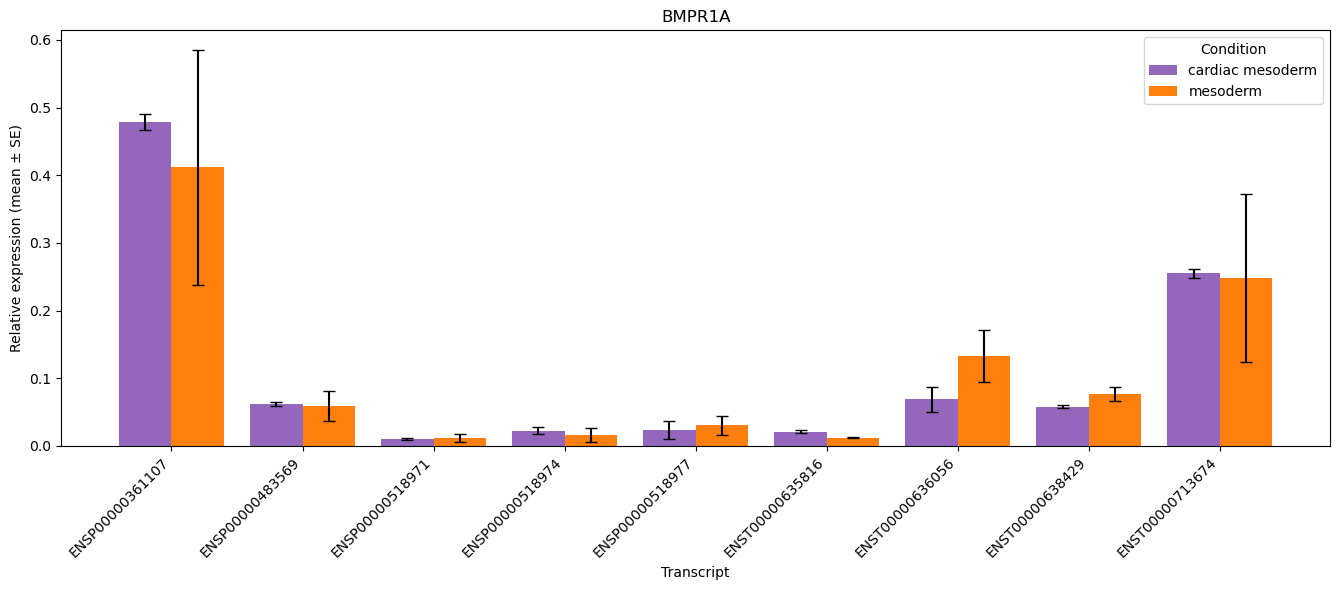

In [62]:
pf.plot_expr_bars(expr_df=meso_cardmeso_expr,
                   gene="BMPR1A",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["mesoderm", "cardiac mesoderm"],
                   how="rel",
                   by="ensembl",
                   condition_colors={"mesoderm": "tab:orange", "cardiac mesoderm": "tab:purple"})

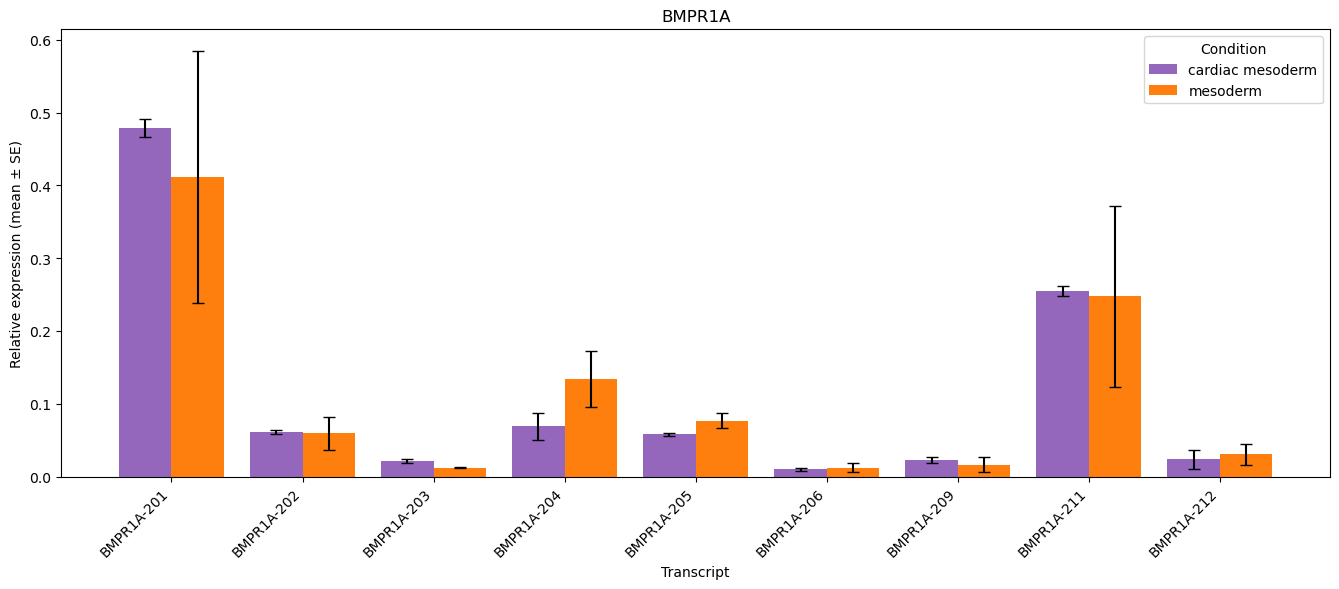

In [63]:
pf.plot_expr_bars(expr_df=meso_cardmeso_expr,
                   gene="BMPR1A",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["mesoderm", "cardiac mesoderm"],
                   how="rel",
                   by="symbol",
                   condition_colors={"mesoderm": "tab:orange", "cardiac mesoderm": "tab:purple"})

In [64]:
meso_vs_cardmeso_deseq[meso_vs_cardmeso_deseq["GeneSymbol"] == "BMPR1A"]

,GeneID,GeneSymbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
3359,ENSG00000107779,BMPR1A,6034.164693,0.44738,0.219262,2.040391,0.041311,0.084418,False


In [65]:
# remove last mesoderm replicate
meso_cardmeso_expr_filt = meso_cardmeso_expr.drop("rel_expr_118892_S14_mesoderm", axis=1)

In [66]:
meso_cardmeso_expr_filt[meso_cardmeso_expr_filt["gene_symbol"] == "BMPR1A"]

,gene,Name,txname,rel_expr_118750_S3_cardiac mesoderm,rel_expr_118752_S4_cardiac mesoderm,rel_expr_118754_S5_cardiac mesoderm,rel_expr_118888_S12_mesoderm,rel_expr_118890_S13_mesoderm,gene_symbol,transcript_symbol
26650,ENSG00000107779,ENSP00000518971,ENST00000713669,0.008416,0.014164,0.008077,0.024112,0.009223,BMPR1A,BMPR1A-206
26651,ENSG00000107779,ENST00000635816,ENST00000635816,0.019419,0.018583,0.025942,0.011002,0.013223,BMPR1A,BMPR1A-203
26652,ENSG00000107779,ENST00000638429,ENST00000638429,0.062206,0.054914,0.056808,0.074873,0.059950,BMPR1A,BMPR1A-205
26653,ENSG00000107779,ENST00000636056,ENST00000636056,0.038180,0.067816,0.101242,0.205231,0.120771,BMPR1A,BMPR1A-204
26654,ENSG00000107779,ENSP00000361107,ENST00000372037,0.493950,0.487304,0.454565,0.262116,0.215999,BMPR1A,BMPR1A-201
26655,ENSG00000107779,ENSP00000518974,ENST00000713672,0.016060,0.031885,0.020453,0.012873,0.035182,BMPR1A,BMPR1A-209
26656,ENSG00000107779,ENST00000713674,ENST00000713674,0.248312,0.269052,0.248083,0.358439,0.384555,BMPR1A,BMPR1A-211
26657,ENSG00000107779,ENSP00000483569,ENST00000480152,0.066409,0.056281,0.061628,0.030224,0.103121,BMPR1A,BMPR1A-202
26658,ENSG00000107779,ENSP00000518977,ENST00000713675,0.047048,0.000000,0.023202,0.021130,0.057976,BMPR1A,BMPR1A-212


In [67]:
pc_alk3 = [ "BMPR1A-201"," BMPR1A-202", "BMPR1A-206", "BMPR1A-209", "BMPR1A-212"]

In [68]:
meso_cardmeso_expr_filt_alk3 = meso_cardmeso_expr_filt[meso_cardmeso_expr_filt["gene_symbol"] == "BMPR1A"]

In [69]:
meso_cardmeso_expr_pc = meso_cardmeso_expr_filt_alk3[meso_cardmeso_expr_filt_alk3["transcript_symbol"].isin(pc_alk3)]
meso_cardmeso_expr_nonpc = meso_cardmeso_expr_filt_alk3[~meso_cardmeso_expr_filt_alk3["transcript_symbol"].isin(pc_alk3)]

In [70]:
meso_cardmeso_expr_pc.sum().to_frame(name="sum")

,sum
gene,ENSG00000107779ENSG00000107779ENSG00000107779E...
Name,ENSP00000518971ENSP00000361107ENSP00000518974E...
txname,ENST00000713669ENST00000372037ENST00000713672E...
rel_expr_118750_S3_cardiac mesoderm,0.565474
rel_expr_118752_S4_cardiac mesoderm,0.533354
rel_expr_118754_S5_cardiac mesoderm,0.506297
rel_expr_118888_S12_mesoderm,0.320231
rel_expr_118890_S13_mesoderm,0.31838
gene_symbol,BMPR1ABMPR1ABMPR1ABMPR1A
transcript_symbol,BMPR1A-206BMPR1A-201BMPR1A-209BMPR1A-212


In [71]:
meso_cardmeso_expr_pc[["rel_expr_118888_S12_mesoderm", "rel_expr_118890_S13_mesoderm"]].sum(axis=0).mean()

0.3193058095

In [72]:
meso_cardmeso_expr_pc[["rel_expr_118750_S3_cardiac mesoderm", "rel_expr_118752_S4_cardiac mesoderm", "rel_expr_118754_S5_cardiac mesoderm"]].sum(axis=0).mean()

0.535041679

In [73]:
meso_cardmeso_expr_nonpc.sum().to_frame(name="sum")

,sum
gene,ENSG00000107779ENSG00000107779ENSG00000107779E...
Name,ENST00000635816ENST00000638429ENST00000636056E...
txname,ENST00000635816ENST00000638429ENST00000636056E...
rel_expr_118750_S3_cardiac mesoderm,0.434526
rel_expr_118752_S4_cardiac mesoderm,0.466646
rel_expr_118754_S5_cardiac mesoderm,0.493703
rel_expr_118888_S12_mesoderm,0.679769
rel_expr_118890_S13_mesoderm,0.681619
gene_symbol,BMPR1ABMPR1ABMPR1ABMPR1ABMPR1A
transcript_symbol,BMPR1A-203BMPR1A-205BMPR1A-204BMPR1A-211BMPR1A...


In [74]:
meso_cardmeso_expr_nonpc[["rel_expr_118888_S12_mesoderm", "rel_expr_118890_S13_mesoderm"]].sum(axis=0).mean()

0.6806941405

In [75]:
meso_cardmeso_expr_nonpc[["rel_expr_118750_S3_cardiac mesoderm", "rel_expr_118752_S4_cardiac mesoderm", "rel_expr_118754_S5_cardiac mesoderm"]].sum(axis=0).mean()

0.4649582886666667

In [76]:
meso_cardmeso_expr_alk3 = meso_cardmeso_expr[meso_cardmeso_expr["gene_symbol"] == "BMPR1A"]
meso_cardmeso_expr_alk3_rep3 = meso_cardmeso_expr_alk3[["transcript_symbol", "rel_expr_118892_S14_mesoderm"]]

In [77]:
meso_cardmeso_expr_alk3_rep3_pc = meso_cardmeso_expr_alk3_rep3[meso_cardmeso_expr_alk3_rep3["transcript_symbol"].isin(pc_alk3)]
meso_cardmeso_expr_alk3_rep3_nonpc = meso_cardmeso_expr_alk3_rep3[~meso_cardmeso_expr_alk3_rep3["transcript_symbol"].isin(pc_alk3)]

In [78]:
meso_cardmeso_expr_alk3_rep3_pc.sum()

transcript_symbol               BMPR1A-206BMPR1A-201BMPR1A-209BMPR1A-212
rel_expr_118892_S14_mesoderm                                    0.772843
dtype: object

In [79]:
meso_cardmeso_expr_alk3_rep3_nonpc.sum()

transcript_symbol               BMPR1A-203BMPR1A-205BMPR1A-204BMPR1A-211BMPR1A...
rel_expr_118892_S14_mesoderm                                             0.227157
dtype: object

In [80]:
print((0.493950+0.487304+0.454565)/3) # 201 cardmeso
print((0.248312+0.269052+0.248083)/3) # 211 cardmeso

0.4786063333333333
0.255149


In [81]:
print((0.262116+0.215999)/2) # 201 meso
print((0.358439+0.384555)/2) # 211 meso

0.2390575
0.37149699999999997


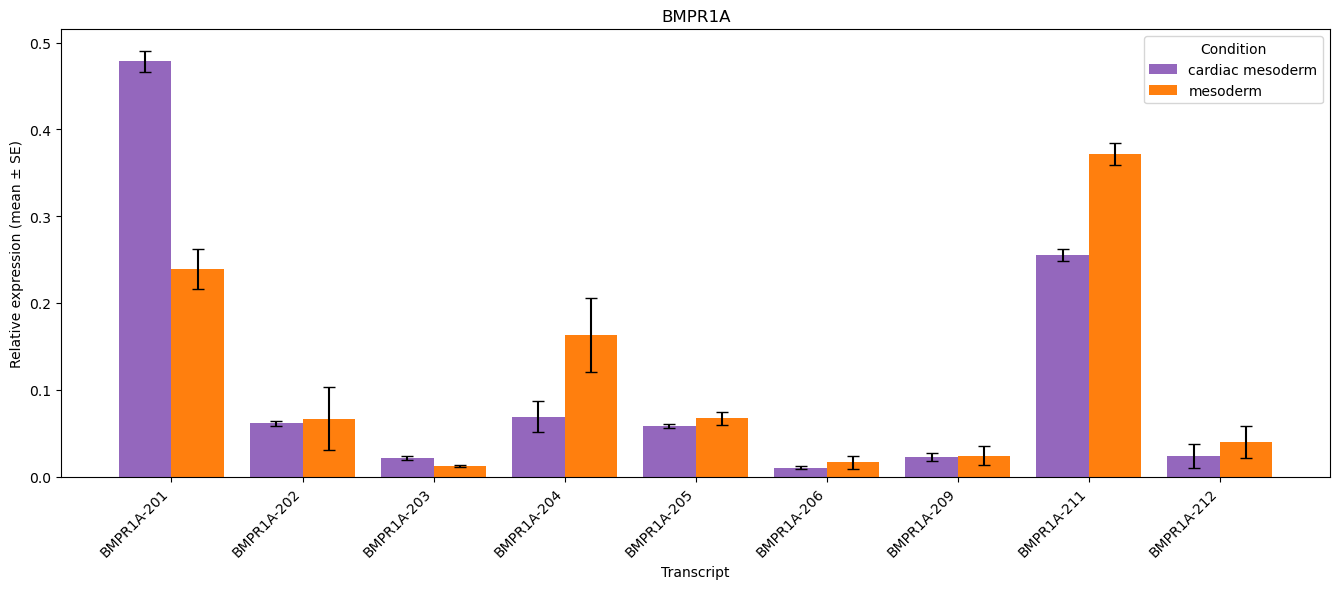

In [82]:
pf.plot_expr_bars(expr_df=meso_cardmeso_expr_filt,
                   gene="BMPR1A",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["mesoderm", "cardiac mesoderm"],
                   how="rel",
                   by="symbol",
                   condition_colors={"mesoderm": "tab:orange", "cardiac mesoderm": "tab:purple"})

In [83]:
pf.feature_architecture_figure(lib_path=lib_path, gene_id="ENSG00000107779", expr_df=meso_cardmeso_expr, fa_index=fa_index, isoforms=["ENSP00000361107"])

In [84]:
# fig = pf.feature_architecture_figure(lib_path=lib_path, gene_id="ENSG00000107779", expr_df=meso_cardmeso_expr, fa_index=fa_index)
# fig.write_image("/home/katharina/msc/figures/alk3_faplot.svg")

In [85]:
# fig = pf.feature_architecture_figure(lib_path=lib_path, gene_id="ENSG00000107779", expr_df=meso_cardmeso_expr, fa_index=fa_index, isoforms=["ENSP00000361107"])
# fig.write_image("/home/katharina/msc/figures/alk3_faplot_only201.svg")

# ATP2A2

In [86]:
cardmeso_vs_cm_filt10top100[cardmeso_vs_cm_filt10top100["gene_symbol"] == "ATP2A2"]

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_CM,TPM_mean_cardiac mesoderm,count_scaled_mean_CM,count_scaled_mean_cardiac mesoderm,gene_symbol,name,BP_GO,BP_GO_Desc,MF_GO,MF_GO_Desc
175,ENSG00000174437,5,0.57255,0.417481,0.184302,0.991645,238.01974,94.288302,39496.455088,17260.177775,ATP2A2,{'Sarcoplasmic/endoplasmic reticulum calcium A...,"GO:0002026,GO:0006874,GO:0006984,GO:0010666,GO...","regulation of the force of heart contraction,i...","GO:0000166,GO:0005246,GO:0005388,GO:0005509,GO...","nucleotide binding,calcium channel regulator a..."


In [87]:
cardmeso_cm_expr[cardmeso_cm_expr["gene_symbol"] == "ATP2A2"]

,gene,Name,txname,rel_expr_118750_S3_cardiac mesoderm,rel_expr_118752_S4_cardiac mesoderm,rel_expr_118754_S5_cardiac mesoderm,rel_expr_125499_S11_CM,rel_expr_125501_S12_CM,rel_expr_125503_S13_CM,gene_symbol,transcript_symbol
26900,ENSG00000174437,ENSP00000311186,ENST00000308664,0.061099,0.068586,0.056473,0.780770,0.750082,0.692761,ATP2A2,ATP2A2-201
26901,ENSG00000174437,ENSP00000440045,ENST00000539276,0.512471,0.542829,0.554209,0.188783,0.191483,0.238317,ATP2A2,ATP2A2-204
26902,ENSG00000174437,ENST00000377685,ENST00000377685,0.266431,0.214909,0.189458,0.000000,0.032641,0.043319,ATP2A2,ATP2A2-203
26903,ENSG00000174437,ENSP00000449454,ENST00000548169,0.159892,0.173616,0.199707,0.030075,0.025550,0.025144,ATP2A2,ATP2A2-207
26904,ENSG00000174437,ENSP00000450407,ENST00000553144,0.000107,0.000060,0.000154,0.000371,0.000243,0.000459,ATP2A2,ATP2A2-212


In [88]:
cardmeso_vs_cm_deseq[cardmeso_vs_cm_deseq["GeneSymbol"] == "ATP2A2"]

,GeneID,GeneSymbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant
13135,ENSG00000174437,ATP2A2,28695.802042,1.147398,0.319955,3.586129,0.000336,0.001382,True


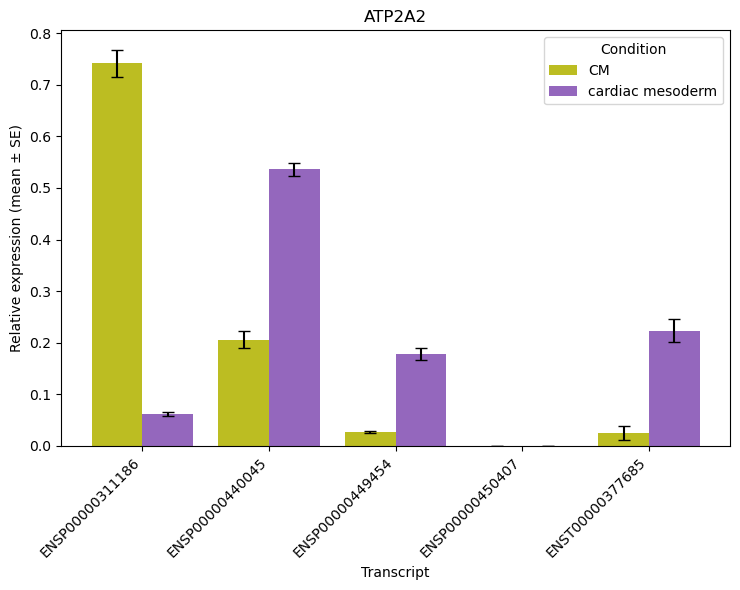

In [89]:
pf.plot_expr_bars(expr_df=cardmeso_cm_expr,
                   gene="ATP2A2",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["CM", "cardiac mesoderm"],
                   how="rel",
                   by="ensembl",
                   condition_colors={"cardiac mesoderm": "tab:purple", "CM": "tab:olive"})

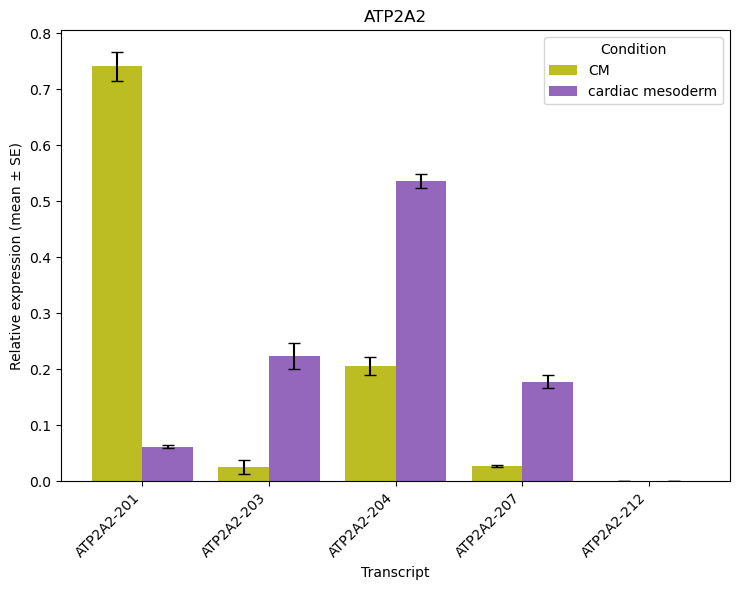

In [90]:
pf.plot_expr_bars(expr_df=cardmeso_cm_expr,
                   gene="ATP2A2",
                   id_type="symbol",
                   mapping=mapping,
                   versioned_tr_id=True,
                   groups=["CM", "cardiac mesoderm"],
                   how="rel",
                   by="symbol",
                   condition_colors={"cardiac mesoderm": "tab:purple", "CM": "tab:olive"})

In [91]:
pf.feature_architecture_figure(lib_path=lib_path, gene_id="ENSG00000174437", expr_df=cardmeso_cm_expr, fa_index=fa_index)

In [92]:
# fig = pf.feature_architecture_figure(lib_path=lib_path, gene_id="ENSG00000174437", expr_df=cardmeso_cm_expr, fa_index=fa_index)
# fig.write_image("/home/katharina/msc/figures/atp2a2_faplot.svg")